# Feedback linearization of the control-affine ROM for the 1D heat equation

In this notebook, we control the temperature field using feedback linearization. Specifically, we exploit the control-affine structure of the ROM to find the input transformation that eliminates the nonlinearities of the latent dynamics.

In [27]:
import os
import pickle
import torch
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Set Times font properties for publication-quality figures
times_font_path = '/usr/share/fonts/truetype/times.ttf'
if os.path.exists(times_font_path):
    times_font = FontProperties(fname=times_font_path, size=8)
    times_font_leg = FontProperties(fname=times_font_path, size=8)
else:
    # fallback to default matplotlib font
    times_font = FontProperties(size=8)
    times_font_leg = FontProperties(size=8)

# identify device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load data
with open("./dataset/heat_equation_data.pkl", "rb") as f:
    data = pickle.load(f)

# Extract data
states, controls = data['all_T_histories'], data['all_U_histories']
print("States shape:", states.shape)
print("Controls shape:", controls.shape)

Using device: cuda
States shape: (2000, 251, 101)
Controls shape: (2000, 251, 101)


### Data Preprocessing

Load and process the data for obtaining the corresponding scaled initial conditions:

In [2]:
from deepe2erom import DataConfig, DataPreprocessor
from torch.utils.data import DataLoader
import numpy as np

# Hyperparameters
lookback = 10
pred_horizon = 5

# Configure data preprocessor
config = DataConfig(
    # Data splitting
    train_split=0.5,
    val_split=0.2,
    test_split=0.3,
    
    # Sequence parameters
    lookback=lookback,             # Use 10 past time steps as input
    pred_horizon=pred_horizon,     # Predict 5 future time steps
    stride=1,                      # No skipping between sequences
    
    # Scaling
    scale_states=False,
    scale_controls=True,
    scale_states_collectively=True,          # Not relevant since scale_states=False
    scale_controls_collectively=True,        
    scaling_method="minmax",                 # Scaling method: "minmax" or "standard"
    
    # Device
    device=device
)

# Initialize data preprocessor
preprocessor = DataPreprocessor(config)

# Process data
processed_data = preprocessor.process_simulations(states, controls)

Scaling controls using:  minmax


### Create and load the trained model

In [3]:
from deepe2erom import create_model

# Hyperparameters
state_dim = states.shape[2]  # (nb_channels, height, width)
control_dim = controls.shape[-1]
latent_dim = 6
control_latent_dim = 6

# Encoder/Decoder Architectures
encoder_arch = [
    {"type": "Linear", "params": {"in_features": state_dim, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": latent_dim}},
]

decoder_arch = [
    {"type": "Linear", "params": {"in_features": latent_dim, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": state_dim}},
]

# Encoder/Decoder Architectures for Control Autoencoder
encoder_arch_control = [
    {"type": "Linear", "params": {"in_features": control_dim, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": control_latent_dim}},
    {"type": "Sigmoid"},
]

decoder_arch_control = [
    {"type": "Linear", "params": {"in_features": control_latent_dim, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": control_dim}},
    {"type": "Sigmoid"},
]

# Dynamics Architectures
# Input to dynamics is: latent_dim * lookback + control_dim * (lookback - 1)
dyn_input_dim = latent_dim * config.lookback + control_latent_dim * (config.lookback - 1)

drift_arch = [
    {"type": "Linear", "params": {"in_features": dyn_input_dim, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": latent_dim}}
]

input_arch = [
    {"type": "Linear", "params": {"in_features": dyn_input_dim, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": latent_dim*control_latent_dim}}
]

model = create_model(
    state_dim=state_dim,
    control_dim=control_dim,
    lookback=config.lookback,
    pred_horizon=config.pred_horizon,
    latent_dim=latent_dim,
    control_latent_dim=control_latent_dim,
    dynamics_type="control_affine",
    drift_arch=drift_arch,
    input_arch=input_arch,
    encoder_arch=encoder_arch,
    decoder_arch=decoder_arch,
    use_control_autoencoder=True,
    control_encoder_arch=encoder_arch_control,
    control_decoder_arch=decoder_arch_control,
    device=device,
    seed=42
)

# load the model
model.load_state_dict(torch.load('./results_control_affine/best_model.pth'))

<All keys matched successfully>

### Reference tracking using feedback linearization

We choose a reference trajectory from the test simulations:

In [66]:
# Reference simulation
sim_idx = 115
sim_length = 140
ref_sim = processed_data['simulations']['test'][sim_idx, :sim_length, :]

# Encode the reference simulation
with torch.no_grad():
    ref_states = ref_sim.states_scaled.unsqueeze(0).to(device)  # Add batch dimension
    z_ref = model.encoder(ref_states).squeeze(0)

# Initialize closed-loop simulation tensors
states_closed_loop = torch.zeros_like(z_ref).to(device)
inputs_closed_loop = torch.zeros((sim_length, control_latent_dim)).to(device)

# Initial states
Z0 = z_ref[0:lookback, :]
print("Initial latent states shape:", Z0.shape)

# Initial controls
U0_high_dim = torch.zeros((lookback - 1, control_dim)).to(device)
# Alternatively, encode initial controls from reference simulation
#U0_high_dim = ref_sim.controls_scaled[0:lookback - 1, :].to(device)
# Encode initial controls
with torch.no_grad():
    U0 = model.control_encoder(U0_high_dim.unsqueeze(0)).squeeze(0)
print("Initial latent controls shape:", U0.shape)

# Save initial conditions
states_closed_loop[0:lookback, :] = Z0
inputs_closed_loop[0:lookback - 1, :] = U0

Initial latent states shape: torch.Size([10, 6])
Initial latent controls shape: torch.Size([9, 6])


Closed-loop simulation to track the reference latent trajectory:

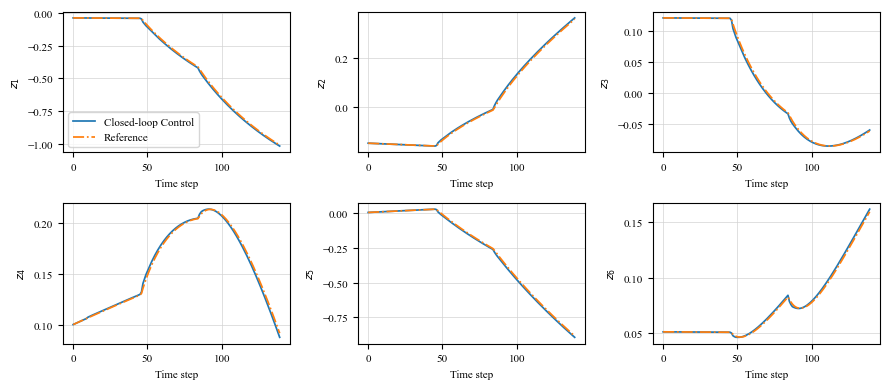

In [67]:
# PID controller gains
n = latent_dim
Kp = 0.8 * torch.eye(n, device=device)
Ki = 1.0 * torch.eye(n, device=device)
Kd = 0.1 * torch.eye(n, device=device)

# Placeholders for PID terms
integral_error = torch.zeros(n, 1, device=device)
last_error = torch.zeros(n, 1, device=device)
# Add a limit to prevent integral "windup"
max_integral = 100.0

# loop over the timesteps
for t in range(lookback, sim_length):
    # build the augmented state/input vector
    ksi = torch.cat((Z0.view(1,-1), U0.view(1,-1)), dim=1)

    # evaluate the model
    a_x = model.dynamics.drift_net(ksi).T                          
    B_x = model.dynamics.input_net(ksi).T.view(n, control_latent_dim)

    # Error terms
    e_k = z_ref[t].view(n,1) - Z0[-1].view(n,1)

    # Integral term
    integral_error += e_k
    integral_error = torch.clamp(integral_error, -max_integral, max_integral) # Anti-windup
    
    # Derivative term
    derivative_error = e_k - last_error
    
    # "virtual" control input
    v_k = (Kp @ e_k) + (Ki @ integral_error) + (Kd @ derivative_error)
    
    # Update last_error for next loop
    last_error = e_k

    # solve for u_k
    rank_B_x = torch.linalg.matrix_rank(B_x)
    if rank_B_x < control_latent_dim: # Check if rank is less than num_inputs
        # warn that B_x is rank deficient
        print(f"Warning: B_x is rank deficient at time step {t}. Rank: {rank_B_x}, Expected: {control_latent_dim}")
        # Use pseudo-inverse
        B_x_inv = torch.linalg.pinv(B_x)
    else:
        B_x_inv = torch.linalg.inv(B_x) 

    u_k = B_x_inv @ ((Z0[-1].view(n,1) + v_k) - a_x)
    #print(f"Time step {t}: Control input u_k: {u_k.view(-1)}")
    # store u
    inputs_closed_loop[t] = u_k.T

    # 4) propagate one step
    next_state = a_x + B_x @ u_k
    states_closed_loop[t] = next_state.T

    # 5) roll the histories forward
    Z0 = torch.cat((Z0[1:], next_state.T), dim=0)
    U0 = torch.cat((U0[1:], u_k.T), dim=0)

# Plot the results
fig, axs = plt.subplots(2, 3, figsize=(9, 4))
axs = axs.flatten()
for t in range(latent_dim):
    axs[t].plot(states_closed_loop[:, t].cpu().detach().numpy(), linestyle='-', color='C0', linewidth=1.25)
    axs[t].plot(z_ref[:, t].cpu().numpy(), color='C1', linestyle='-.', linewidth=1.25)
    #axs[t].plot(pred_latents[:, t], linestyle='--', color='C1', linewidth=1.25)
    axs[t].set_ylabel(r"$z_{}$".format(t+1), fontproperties=times_font)
    axs[t].set_xlabel('Time step', fontproperties=times_font)
    if t == 0:
        axs[t].legend(['Closed-loop Control','Reference'], prop=times_font_leg)
    axs[t].grid(color='lightgray', linestyle='-', linewidth=0.5)
for ax in axs:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(times_font)
plt.tight_layout()
fig.savefig('./results_control_affine/latent_states_control.pdf', bbox_inches='tight')

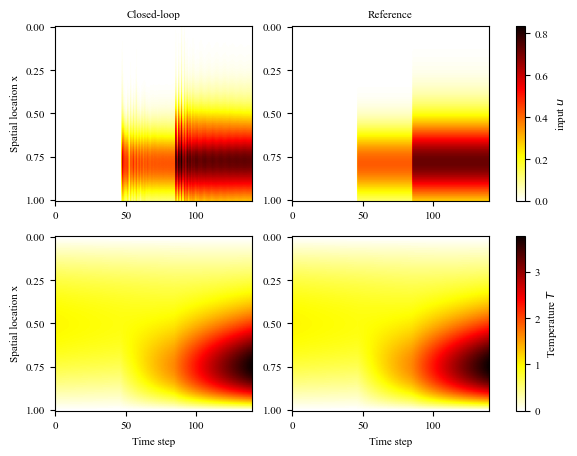

In [68]:
# decode the inputs to high-dimensional space
with torch.no_grad():
    inputs_closed_loop_high_dim = model.control_decoder(inputs_closed_loop.unsqueeze(0)).squeeze(0)
    # decode the closed-loop latent states
    decoded_states = model.decoder(states_closed_loop.unsqueeze(0)).squeeze(0).cpu().numpy()

# Prepare data and find global min/max for consistent colormap
data_cl = inputs_closed_loop_high_dim.cpu().detach().numpy().T
data_ref = ref_sim.controls_scaled.cpu().numpy().T
vmin = min(data_cl.min(), data_ref.min())
vmax = max(data_cl.max(), data_ref.max())

# ===== ( control, temperature) =====
fig, axs = plt.subplots(2, 2, figsize=(7, 5))
camp_control = 'hot_r'
cmap_temp = 'hot_r'

# --- Control ---
ax = axs[0, 0]
im1 = ax.imshow(data_cl, aspect='auto', cmap=camp_control, vmin=vmin, vmax=vmax)
ax.set_title("Closed-loop", fontproperties=times_font)

# spatial coordinate labeling
ny = data_cl.shape[0]
yticks = np.linspace(0, ny - 1, 5)
ylabels = [f"{v:.2f}" for v in np.linspace(0, 1, 5)]
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('Spatial location x', fontproperties=times_font)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(times_font)

ax = axs[0, 1]
im2 = ax.imshow(data_ref, aspect='auto', cmap=camp_control, vmin=vmin, vmax=vmax)
ax.set_title("Reference", fontproperties=times_font)

# spatial coordinate labeling
ny = data_ref.shape[0]
yticks = np.linspace(0, ny - 1, 5)
ylabels = [f"{v:.2f}" for v in np.linspace(0, 1, 5)]
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(times_font)

# --- Temperature / States ---
ax = axs[1, 0]
im3 = ax.imshow(decoded_states.T, aspect='auto', cmap=cmap_temp)
ax.set_xlabel('Time step', fontproperties=times_font)

# spatial coordinate labeling
ny = decoded_states.T.shape[0]
yticks = np.linspace(0, ny - 1, 5)
ylabels = [f"{v:.2f}" for v in np.linspace(0, 1, 5)]
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('Spatial location x', fontproperties=times_font)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(times_font)


ax = axs[1, 1]
im4 = ax.imshow(ref_sim.states_scaled.cpu().numpy().T, aspect='auto', cmap=cmap_temp)
ax.set_xlabel('Time step', fontproperties=times_font)

# spatial coordinate labeling
ny = ref_sim.states_scaled.cpu().numpy().T.shape[0]
yticks = np.linspace(0, ny - 1, 5)
ylabels = [f"{v:.2f}" for v in np.linspace(0, 1, 5)]
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(times_font)

# Control colorbar
cbar1 = fig.colorbar(im1, ax=axs[0, :].ravel().tolist())
cbar1.ax.set_ylabel(r'input $u$', fontproperties=times_font)
for label in cbar1.ax.get_yticklabels():
    label.set_fontproperties(times_font)

# State colorbar
cbar2 = fig.colorbar(im4, ax=axs[1, :].ravel().tolist())
cbar2.set_label(r'Temperature $T$', fontproperties=times_font)
for label in cbar2.ax.get_yticklabels():
    label.set_fontproperties(times_font)

fig.savefig('./results_control_affine/control_and_states.pdf', bbox_inches='tight')